**Sarcasm Preservation in Machine Translation: Effects on Automatic Detection in English–Russian Settings** - Master thesis

Part 1 - Sarcasm detetion (+ evaluation, visualization)

Part 2 - Machine Translation (EN-RU)

Part 3 - Sarcasm detection on the MT-text (+ evaluation, visualization)

Part 4 - Comparison of translation techniques

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os

BASE_PATH = "/content/drive/MyDrive/sarcasm_thesis"

folders = [
    "models",
    "results",
    "logs",
    "plots",
    "data"
]

for folder in folders:
    os.makedirs(os.path.join(BASE_PATH, folder), exist_ok=True)

In [ ]:
!pip install transformers datasets scikit-learn matplotlib seaborn

In [ ]:
import torch
print(torch.cuda.is_available())

True


In [ ]:
from datasets import load_dataset

dataset_ru = load_dataset("Kostya165/ru_emotion_dvach")
df_ru = dataset_ru["train"].to_pandas()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

train_part_1.csv: 0.00B [00:00, ?B/s]

train_part_2.csv: 0.00B [00:00, ?B/s]

train_part_3.csv: 0.00B [00:00, ?B/s]

...

train_part_5.csv: 0.00B [00:00, ?B/s]

train_part_6.csv: 0.00B [00:00, ?B/s]

valid.csv: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/59061 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2507 [00:00<?, ? examples/s]

In [ ]:
df_ru.head()
df_ru.columns

Index(['text', 'label'], dtype='object')

In [ ]:
import pandas as pd

df_en = pd.read_json(f"{BASE_PATH}/Sarcasm_Headlines_Dataset.json", lines=True)

In [ ]:
df_en = df_en.rename(columns={
    "headline": "text",
    "is_sarcastic": "label"
})

In [ ]:
df_en = df_en[["text", "label"]].dropna()
df_ru = df_ru[["text", "label"]].dropna()

In [ ]:
df_ru["label"] = df_ru["label"].apply(lambda x: 1 if x == "sarcasm" else 0)

In [ ]:
df_en.head()

,text,label
0,former versace store clerk sues over secret 'b...,0
1,the 'roseanne' revival catches up to our thorn...,0
2,mom starting to fear son's web series closest ...,1
3,"boehner just wants wife to listen, not come up...",1
4,j.k. rowling wishes snape happy birthday in th...,0


In [ ]:
df_en['label'].value_counts()

,count
label,
0,14985
1,11724


In [ ]:
df_en_sarcasm = df_en[df_en['label'] == 1]
df_en_non = df_en[df_en['label'] == 0]

df_en_non_sampled = df_en_non.sample(
    n=len(df_en_sarcasm),
    random_state=42
)

df_en_balanced = pd.concat([
    df_en_sarcasm,
    df_en_non_sampled
]).sample(frac=1, random_state=42)

In [ ]:
df_en_balanced['label'].value_counts()

,count
label,
1,11724
0,11724


In [ ]:
df_ru.head()

,text,label
0,"Я боюсь, что из-за контроля сварных соединений...",0
1,"О, ДМС - это просто сказка для бедных! Кто бы ...",1
2,Это потрясающий фильм! Я в восторге! 10/10,0
3,"Ой, какие же законы и судебная практика разные...",1
4,"а что если они правы, что если войн не станет ...",0


In [ ]:
df_ru['label'].value_counts()

,count
label,
0,47361
1,11693


In [ ]:
df_sarcasm = df_ru[df_ru['label'] == 1]
df_non = df_ru[df_ru['label'] == 0]

df_non_sampled = df_non.sample(n=len(df_sarcasm), random_state=42)

df_ru_balanced = pd.concat([
    df_sarcasm,
    df_non_sampled
]).sample(frac=1, random_state=42)

In [ ]:
df_ru_balanced['label'].value_counts()

,count
label,
0,11693
1,11693


In [ ]:
TOTAL_SIZE = 20000

df_en_balanced = df_en_balanced.sample(
    n=TOTAL_SIZE,
    random_state=42
)

df_ru_balanced = df_ru_balanced.sample(
    n=TOTAL_SIZE,
    random_state=42
)

In [ ]:
from sklearn.model_selection import train_test_split

train_val_en, test_en = train_test_split(
    df_en_balanced,
    test_size=0.15,
    stratify=df_en_balanced['label'],
    random_state=42
)

train_en, val_en = train_test_split(
    train_val_en,
    test_size=3000,
    stratify=train_val_en['label'],
    random_state=42
)

In [ ]:
train_val_ru, test_ru = train_test_split(
    df_ru_balanced,
    test_size=0.15,
    stratify=df_ru_balanced['label'],
    random_state=42
)

train_ru, val_ru = train_test_split(
    train_val_ru,
    test_size=3000,
    stratify=train_val_ru['label'],
    random_state=42
)

In [ ]:
print("\nEN sizes:")
print(len(train_en), len(val_en), len(test_en))

print("\nRU sizes:")
print(len(train_ru), len(val_ru), len(test_ru))

print("\nEN label distribution:")
print(train_en['label'].value_counts(normalize=True))

print("\nRU label distribution:")
print(train_ru['label'].value_counts(normalize=True))


EN sizes:
14000 3000 3000

RU sizes:
14000 3000 3000

EN label distribution:
label
0    0.5005
1    0.4995
Name: proportion, dtype: float64

RU label distribution:
label
1    0.501143
0    0.498857
Name: proportion, dtype: float64


In [ ]:
train_ru.to_csv(f"{BASE_PATH}/data/train_ru.csv", index=False)
val_ru.to_csv(f"{BASE_PATH}/data/val_ru.csv", index=False)
test_ru.to_csv(f"{BASE_PATH}/data/test_ru.csv", index=False)

train_en.to_csv(f"{BASE_PATH}/data/train_en.csv", index=False)
val_en.to_csv(f"{BASE_PATH}/data/val_en.csv", index=False)
test_en.to_csv(f"{BASE_PATH}/data/test_en.csv", index=False)

# **Part 1**

**Model:** https://huggingface.co/FacebookAI/xlm-roberta-base

**Dataset RU:** https://huggingface.co/datasets/Kostya165/ru_emotion_dvach (sarcasm is separately marked)

**Dataset EN:** https://www.kaggle.com/datasets/rmisra/news-headlines-dataset-for-sarcasm-detection


**Training combinations for fine-tuning:**

1. Only EN

2. Only RU

3. Combined EN + RU

4. Sequential fine-tuning: First EN and then RU




Outcome - choose the best model to use in part 3. It is important that the model can sucsesfully detect sarcasm in both languages so that post-MT-text results would be valid

**Only EN**

In [ ]:
import pandas as pd

train_en = pd.read_csv(f"{BASE_PATH}/data/train_en.csv")
val_en = pd.read_csv(f"{BASE_PATH}/data/val_en.csv")
test_en = pd.read_csv(f"{BASE_PATH}/data/test_en.csv")

In [ ]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("FacebookAI/xlm-roberta-base")

In [ ]:
def tokenize(batch):
    return tokenizer(
        batch["text"],
        truncation=True
    )

In [ ]:
from datasets import Dataset

train_en_ds = Dataset.from_pandas(train_en)
val_en_ds = Dataset.from_pandas(val_en)
test_en_ds = Dataset.from_pandas(test_en)

In [ ]:
train_en_ds = train_en_ds.map(tokenize, batched=True)
val_en_ds = val_en_ds.map(tokenize, batched=True)
test_en_ds = test_en_ds.map(tokenize, batched=True)

Map:   0%|          | 0/14000 [00:00<?, ? examples/s]

Map:   0%|          | 0/3000 [00:00<?, ? examples/s]

Map:   0%|          | 0/3000 [00:00<?, ? examples/s]

In [ ]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    "FacebookAI/xlm-roberta-base",
    num_labels=2
)

model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: FacebookAI/xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.weight     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir=f"{BASE_PATH}/models/en_only",
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    logging_dir=f"{BASE_PATH}/logs",
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=5,
    learning_rate=2e-5,
    weight_decay=0.01,
    save_total_limit=2,
    seed=42
)

In [ ]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = logits.argmax(axis=1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='binary')
    acc = accuracy_score(labels, preds)
    return {"accuracy": acc, "f1": f1}

In [ ]:
from transformers import Trainer, DataCollatorWithPadding

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_en_ds,
    eval_dataset=val_en_ds,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

In [ ]:
trainer.train()
trainer.evaluate()

In [ ]:
test_results = trainer.evaluate(test_en_ds)

print(test_results)

trainer.save_model(f"{BASE_PATH}/models/en_only_final")

In [ ]:
from transformers import AutoModelForSequenceClassification, Trainer, TrainingArguments, DataCollatorWithPadding

model_combined = AutoModelForSequenceClassification.from_pretrained(
    f"{BASE_PATH}/models/en_only_final"
)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

eval_args = TrainingArguments(
    output_dir="./tmp_eval",
    per_device_eval_batch_size=16,
    report_to=[],
    logging_strategy="no"
)

trainer_evaluate = Trainer(
    model=model_combined,
    args=eval_args,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

In [ ]:
en_on_ru_results = trainer_evaluate.evaluate(test_ru_ds)

print("\nEN model on RU test:")
print(en_on_ru_results)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

preds_ru = trainer_evaluate.predict(test_ru_ds)

y_true_ru = preds_ru.label_ids

y_pred_ru = np.argmax(preds_ru.predictions, axis=1)

cm_ru = confusion_matrix(y_true_ru, y_pred_ru)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_ru)

disp.plot()

plt.title("EN Model — RU Test Set")

plt.show()

**Only RU**

In [ ]:
import pandas as pd

train_ru = pd.read_csv(f"{BASE_PATH}/data/train_ru.csv")
val_ru = pd.read_csv(f"{BASE_PATH}/data/val_ru.csv")
test_ru = pd.read_csv(f"{BASE_PATH}/data/test_ru.csv")

In [ ]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("FacebookAI/xlm-roberta-base")

In [ ]:
def tokenize(batch):
    return tokenizer(
        batch["text"],
        truncation=True
    )

In [ ]:
from datasets import Dataset

train_ru_ds = Dataset.from_pandas(train_ru)
val_ru_ds = Dataset.from_pandas(val_ru)
test_ru_ds = Dataset.from_pandas(test_ru)

In [ ]:
train_ru_ds = train_ru_ds.map(tokenize, batched=True)
val_ru_ds = val_ru_ds.map(tokenize, batched=True)
test_ru_ds = test_ru_ds.map(tokenize, batched=True)

Map:   0%|          | 0/14000 [00:00<?, ? examples/s]

Map:   0%|          | 0/3000 [00:00<?, ? examples/s]

Map:   0%|          | 0/3000 [00:00<?, ? examples/s]

In [ ]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    "FacebookAI/xlm-roberta-base",
    num_labels=2
)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: FacebookAI/xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.weight     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir=f"{BASE_PATH}/models/ru_only",
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    logging_dir=f"{BASE_PATH}/logs",
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=5,
    learning_rate=2e-5,
    weight_decay=0.01,
    save_total_limit=2,
    seed=42
)

In [ ]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = logits.argmax(axis=1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='binary')
    acc = accuracy_score(labels, preds)
    return {"accuracy": acc, "f1": f1}

In [ ]:
from transformers import Trainer, DataCollatorWithPadding

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ru_ds,
    eval_dataset=val_ru_ds,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

In [ ]:
trainer.train()
trainer.evaluate()

In [ ]:
test_results = trainer.evaluate(test_ru_ds)

print(test_results)

trainer.save_model(f"{BASE_PATH}/models/ru_only_final")

**Combined EN + RU**

In [ ]:
import pandas as pd

train_en = pd.read_csv(f"{BASE_PATH}/data/train_en.csv")
val_en = pd.read_csv(f"{BASE_PATH}/data/val_en.csv")
test_en = pd.read_csv(f"{BASE_PATH}/data/test_en.csv")

train_ru = pd.read_csv(f"{BASE_PATH}/data/train_ru.csv")
val_ru = pd.read_csv(f"{BASE_PATH}/data/val_ru.csv")
test_ru = pd.read_csv(f"{BASE_PATH}/data/test_ru.csv")

In [ ]:
train_lang = 7000
val_lang = 1500
test_lang = 1500

train_en_small = train_en.sample(
    n=train_lang,
    random_state=42
)

train_ru_small = train_ru.sample(
    n=train_lang,
    random_state=42
)

val_en_small = val_en.sample(
    n=val_lang,
    random_state=42
)

val_ru_small = val_ru.sample(
    n=val_lang,
    random_state=42
)

test_en_small = test_en.sample(
    n=test_lang,
    random_state=42
)

test_ru_small = test_ru.sample(
    n=test_lang,
    random_state=42
)

In [ ]:
train_combined = pd.concat([
    train_en_small,
    train_ru_small
]).sample(frac=1, random_state=42)

val_combined = pd.concat([
    val_en_small,
    val_ru_small
]).sample(frac=1, random_state=42)

test_combined = pd.concat([
    test_en_small,
    test_ru_small
]).sample(frac=1, random_state=42)

In [ ]:
train_combined.to_csv(
    f"{BASE_PATH}/data/train_combined.csv",
    index=False
)

val_combined.to_csv(
    f"{BASE_PATH}/data/val_combined.csv",
    index=False
)

test_combined.to_csv(
    f"{BASE_PATH}/data/test_combined.csv",
    index=False
)

In [ ]:
print("\nTrain size:", len(train_combined))
print("Validation size:", len(val_combined))
print("Test size:", len(test_combined))

print("\nTrain label distribution:")
print(train_combined["label"].value_counts(normalize=True))

print("\nValidation label distribution:")
print(val_combined["label"].value_counts(normalize=True))

print("\nTest label distribution:")
print(test_combined["label"].value_counts(normalize=True))


Train size: 14000
Validation size: 3000
Test size: 3000

Train label distribution:
label
0    0.51
1    0.49
Name: proportion, dtype: float64

Validation label distribution:
label
1    0.500667
0    0.499333
Name: proportion, dtype: float64

Test label distribution:
label
1    0.501
0    0.499
Name: proportion, dtype: float64


In [ ]:
from datasets import Dataset

train_combined_ds = Dataset.from_pandas(train_combined)
val_combined_ds = Dataset.from_pandas(val_combined)
test_combined_ds = Dataset.from_pandas(test_combined)

In [ ]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("FacebookAI/xlm-roberta-base")

def tokenize(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        max_length=128
    )

In [ ]:
train_combined_ds = train_combined_ds.map(tokenize, batched=True)
val_combined_ds = val_combined_ds.map(tokenize, batched=True)
test_combined_ds = test_combined_ds.map(tokenize, batched=True)

Map:   0%|          | 0/14000 [00:00<?, ? examples/s]

Map:   0%|          | 0/3000 [00:00<?, ? examples/s]

Map:   0%|          | 0/3000 [00:00<?, ? examples/s]

In [ ]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    "FacebookAI/xlm-roberta-base",
    num_labels=2
)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: FacebookAI/xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.weight     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir=f"{BASE_PATH}/models/combined_only",
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    logging_dir=f"{BASE_PATH}/logs",
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=5,
    learning_rate=2e-5,
    weight_decay=0.01,
    save_total_limit=2,
    seed=42
)

In [ ]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = logits.argmax(axis=1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='binary')
    acc = accuracy_score(labels, preds)
    return {"accuracy": acc, "f1": f1}

In [ ]:
from transformers import Trainer, DataCollatorWithPadding

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_combined_ds,
    eval_dataset=val_combined_ds,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

In [ ]:
trainer.train()
trainer.evaluate()

In [ ]:
test_results = trainer.evaluate(test_combined_ds)

print(test_results)

trainer.save_model(f"{BASE_PATH}/models/combined_only")

In [ ]:
from transformers import AutoModelForSequenceClassification, Trainer, TrainingArguments, DataCollatorWithPadding

model_combined = AutoModelForSequenceClassification.from_pretrained(
    f"{BASE_PATH}/models/combined_only"
)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

eval_args = TrainingArguments(
    output_dir="./tmp_eval",
    per_device_eval_batch_size=16,
    report_to=[],
    logging_strategy="no"
)

trainer_evaluate = Trainer(
    model=model_combined,
    args=eval_args,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

In [ ]:
combined_on_ru_results = trainer_evaluate.evaluate(test_ru_ds)

print("\nCombined model on RU test:")
print(combined_on_ru_results)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

preds_ru = trainer_evaluate.predict(test_ru_ds)

y_true_ru = preds_ru.label_ids

y_pred_ru = np.argmax(preds_ru.predictions, axis=1)

cm_ru = confusion_matrix(y_true_ru, y_pred_ru)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_ru)

disp.plot()

plt.title("Combined Model — RU Test Set")

plt.show()

In [ ]:
combined_on_en_results = trainer_evaluate.evaluate(test_en_ds)

print("\nCombined model on EN test:")
print(combined_on_ru_results)

In [ ]:
preds_en = trainer_evaluate.predict(test_en_ds)

y_true_en = preds_en.label_ids
y_pred_en = np.argmax(preds_en.predictions, axis=1)

cm_en = confusion_matrix(y_true_en, y_pred_en)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_en)

disp.plot()

plt.title("Combined Model — EN Test Set")

plt.show()

**Sequential training**

In [ ]:

import pandas as pd
from datasets import Dataset

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding
)

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support
)

In [ ]:

train_en = pd.read_csv(f"{BASE_PATH}/data/train_en.csv")
val_en = pd.read_csv(f"{BASE_PATH}/data/val_en.csv")
test_en = pd.read_csv(f"{BASE_PATH}/data/test_en.csv")

train_ru = pd.read_csv(f"{BASE_PATH}/data/train_ru.csv")
val_ru = pd.read_csv(f"{BASE_PATH}/data/val_ru.csv")
test_ru = pd.read_csv(f"{BASE_PATH}/data/test_ru.csv")

In [ ]:

train_en_ds = Dataset.from_pandas(train_en)
val_en_ds = Dataset.from_pandas(val_en)
test_en_ds = Dataset.from_pandas(test_en)

train_ru_ds = Dataset.from_pandas(train_ru)
val_ru_ds = Dataset.from_pandas(val_ru)
test_ru_ds = Dataset.from_pandas(test_ru)

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(
    "FacebookAI/xlm-roberta-base"
)

def tokenize(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        max_length=128
    )

In [ ]:
train_en_ds = train_en_ds.map(tokenize, batched=True)
val_en_ds = val_en_ds.map(tokenize, batched=True)
test_en_ds = test_en_ds.map(tokenize, batched=True)

train_ru_ds = train_ru_ds.map(tokenize, batched=True)
val_ru_ds = val_ru_ds.map(tokenize, batched=True)
test_ru_ds = test_ru_ds.map(tokenize, batched=True)

Map:   0%|          | 0/14000 [00:00<?, ? examples/s]

Map:   0%|          | 0/3000 [00:00<?, ? examples/s]

Map:   0%|          | 0/3000 [00:00<?, ? examples/s]

Map:   0%|          | 0/14000 [00:00<?, ? examples/s]

Map:   0%|          | 0/3000 [00:00<?, ? examples/s]

Map:   0%|          | 0/3000 [00:00<?, ? examples/s]

In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(
    f"{BASE_PATH}/models/en_only_final"
)

In [ ]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir=f"{BASE_PATH}/models/sequential_en_ru",
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    logging_dir=f"{BASE_PATH}/logs",
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=5,
    learning_rate=2e-5,
    weight_decay=0.01,
    save_total_limit=2,
    seed=42
)

In [ ]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = logits.argmax(axis=1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='binary')
    acc = accuracy_score(labels, preds)
    return {"accuracy": acc, "f1": f1}

In [ ]:
from transformers import Trainer, DataCollatorWithPadding

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ru_ds,
    eval_dataset=val_ru_ds,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

In [ ]:
trainer.train()
trainer.evaluate()

In [ ]:
test_results = trainer.evaluate(test_ru_ds)

print(test_results)

trainer.save_model(f"{BASE_PATH}/models/sequential_en_ru")

In [ ]:
from transformers import Trainer, DataCollatorWithPadding, TrainingArguments, AutoModelForSequenceClassification

model_sequential = AutoModelForSequenceClassification.from_pretrained(
    f"{BASE_PATH}/models/sequential_en_ru"
)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

eval_args_seq = TrainingArguments(
    output_dir=f"{BASE_PATH}/tmp_eval_sequential",
    per_device_eval_batch_size=16,
    report_to=[],
    logging_strategy="no"
)

trainer_seq = Trainer(
    model=model_sequential,
    args=eval_args_seq,
    data_collator=data_collator
)

test_results_seq_en = trainer_seq.evaluate(test_en_ds)

print(test_results)

In [ ]:
test_results_seq_ru = trainer_seq.evaluate(test_ru_ds)

print("\nEN results after Seq training:")
print(test_results_seq_ru)

# Part 1.5 - Test sets evaluation + visualization

In [ ]:
from transformers import (Trainer, TrainingArguments, DataCollatorWithPadding)
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support)

def compute_metrics(eval_pred):

    logits, labels = eval_pred

    preds = logits.argmax(axis=1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        preds,
        average="binary"
    )

    acc = accuracy_score(labels, preds)

    return {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

In [ ]:
from transformers import AutoModelForSequenceClassification, Trainer, TrainingArguments, DataCollatorWithPadding, AutoTokenizer

model_sequential = AutoModelForSequenceClassification.from_pretrained(
    f"{BASE_PATH}/models/sequential_en_ru"
)

tokenizer = AutoTokenizer.from_pretrained(f"{BASE_PATH}/models/sequential_en_ru")

data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer
)

eval_args_seq = TrainingArguments(
    output_dir="./tmp",
    per_device_eval_batch_size=16,
    report_to=[],
    logging_strategy="no"
)

trainer_seq = Trainer(
    model=model_sequential,
    args=eval_args_seq,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

In [ ]:
seq_on_en = trainer_seq.evaluate(test_en_ds)

In [ ]:
print(seq_on_en)

{'eval_loss': 0.8089487552642822, 'eval_model_preparation_time': 0.0031, 'eval_accuracy': 0.7356666666666667, 'eval_precision': 0.8723628691983122, 'eval_recall': 0.5517011340893929, 'eval_f1': 0.6759297098487944, 'eval_runtime': 5.5596, 'eval_samples_per_second': 539.604, 'eval_steps_per_second': 33.815}


In [ ]:
seq_on_ru = trainer_seq.evaluate(test_ru_ds)

In [ ]:
print(seq_on_ru)

{'eval_loss': 0.2171006202697754, 'eval_model_preparation_time': 0.0031, 'eval_accuracy': 0.9413333333333334, 'eval_precision': 0.9356955380577427, 'eval_recall': 0.9481382978723404, 'eval_f1': 0.9418758256274768, 'eval_runtime': 15.4922, 'eval_samples_per_second': 193.646, 'eval_steps_per_second': 12.135}


In [ ]:
model_en = AutoModelForSequenceClassification.from_pretrained(
    f"{BASE_PATH}/models/en_only_final"
)

tokenizer = AutoTokenizer.from_pretrained(f"{BASE_PATH}/models/en_only_final")

data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer
)

eval_args_seq = TrainingArguments(
    output_dir="./tmp",
    per_device_eval_batch_size=16,
    report_to=[],
    logging_strategy="no"
)

trainer_en = Trainer(
    model=model_en,
    args=eval_args_seq,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

In [ ]:
en_on_en = trainer_en.evaluate(test_en_ds)

In [ ]:
print(en_on_en)

{'eval_loss': 0.3095717132091522, 'eval_model_preparation_time': 0.0026, 'eval_accuracy': 0.917, 'eval_precision': 0.9263301500682128, 'eval_recall': 0.9059372915276851, 'eval_f1': 0.9160202360876897, 'eval_runtime': 4.9058, 'eval_samples_per_second': 611.523, 'eval_steps_per_second': 38.322}


In [ ]:
en_on_ru = trainer_en.evaluate(test_ru_ds)

In [ ]:
print(en_on_ru)

{'eval_loss': 2.965640068054199, 'eval_model_preparation_time': 0.0026, 'eval_accuracy': 0.502, 'eval_precision': 0.511520737327189, 'eval_recall': 0.14760638297872342, 'eval_f1': 0.22910216718266255, 'eval_runtime': 15.8187, 'eval_samples_per_second': 189.648, 'eval_steps_per_second': 11.885}


In [ ]:
model_ru = AutoModelForSequenceClassification.from_pretrained(
    f"{BASE_PATH}/models/ru_only_final"
)

tokenizer = AutoTokenizer.from_pretrained(f"{BASE_PATH}/models/ru_only_final")

data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer
)

eval_args_seq = TrainingArguments(
    output_dir="./tmp",
    per_device_eval_batch_size=16,
    report_to=[],
    logging_strategy="no"
)

trainer_ru = Trainer(
    model=model_ru,
    args=eval_args_seq,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

Loading weights:   0%|          | 0/201 [00:01<?, ?it/s]

In [ ]:
ru_on_ru = trainer_ru.evaluate(test_ru_ds)

In [ ]:
print(ru_on_ru)

{'eval_loss': 0.32413363456726074, 'eval_model_preparation_time': 0.0059, 'eval_accuracy': 0.945, 'eval_precision': 0.9551325628823929, 'eval_recall': 0.9341755319148937, 'eval_f1': 0.9445378151260504, 'eval_runtime': 16.1416, 'eval_samples_per_second': 185.855, 'eval_steps_per_second': 11.647}


In [ ]:
ru_on_en = trainer_ru.evaluate(test_en_ds)

In [ ]:
print(ru_on_en)

{'eval_loss': 3.2352981567382812, 'eval_model_preparation_time': 0.0059, 'eval_accuracy': 0.49233333333333335, 'eval_precision': 0.4589041095890411, 'eval_recall': 0.08939292861907938, 'eval_f1': 0.14963707426018985, 'eval_runtime': 5.2024, 'eval_samples_per_second': 576.652, 'eval_steps_per_second': 36.137}


In [ ]:
model_combined = AutoModelForSequenceClassification.from_pretrained(
    f"{BASE_PATH}/models/combined_only"
)

tokenizer = AutoTokenizer.from_pretrained(f"{BASE_PATH}/models/combined_only")

data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer
)

eval_args_seq = TrainingArguments(
    output_dir="./tmp",
    per_device_eval_batch_size=16,
    report_to=[],
    logging_strategy="no"
)

trainer_combined = Trainer(
    model=model_combined,
    args=eval_args_seq,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

In [ ]:
combined_on_ru = trainer_combined.evaluate(test_ru_ds)


In [ ]:
print(combined_on_ru)

{'eval_loss': 0.33612558245658875, 'eval_model_preparation_time': 0.0027, 'eval_accuracy': 0.938, 'eval_precision': 0.9464769647696477, 'eval_recall': 0.9288563829787234, 'eval_f1': 0.9375838926174497, 'eval_runtime': 16.4026, 'eval_samples_per_second': 182.897, 'eval_steps_per_second': 11.462}


In [ ]:
combined_on_en = trainer_combined.evaluate(test_en_ds)

In [ ]:
print(combined_on_en)

{'eval_loss': 0.6002283692359924, 'eval_model_preparation_time': 0.0027, 'eval_accuracy': 0.894, 'eval_precision': 0.9155524278676987, 'eval_recall': 0.8679119412941961, 'eval_f1': 0.8910958904109589, 'eval_runtime': 5.347, 'eval_samples_per_second': 561.067, 'eval_steps_per_second': 35.16}


In [ ]:
import pandas as pd

results_df = pd.DataFrame([
     {
        "Model": "RU-only",
        "Test Set": "RU",
        "Accuracy": ru_on_ru["eval_accuracy"],
        "Precision": ru_on_ru["eval_precision"],
        "Recall": ru_on_ru["eval_recall"],
        "F1": ru_on_ru["eval_f1"]

    },

    {
        "Model": "RU-only",
        "Test Set": "EN",
        "Accuracy": ru_on_en["eval_accuracy"],
        "Precision": ru_on_en["eval_precision"],
        "Recall": ru_on_en["eval_recall"],
        "F1": ru_on_en["eval_f1"]
    },

    {
        "Model": "EN-only",
        "Test Set": "EN",
        "Accuracy": en_on_en["eval_accuracy"],
        "Precision": en_on_en["eval_precision"],
        "Recall": en_on_en["eval_recall"],
        "F1": en_on_en["eval_f1"]
    },

    {
        "Model": "EN-only",
        "Test Set": "RU",
        "Accuracy": en_on_ru["eval_accuracy"],
        "Precision": en_on_ru["eval_precision"],
        "Recall": en_on_ru["eval_recall"],
        "F1": en_on_ru["eval_f1"]
    },

    {
        "Model": "Combined",
        "Test Set": "EN",
        "Accuracy": combined_on_en["eval_accuracy"],
        "Precision": combined_on_en["eval_precision"],
        "Recall": combined_on_en["eval_recall"],
        "F1": combined_on_en["eval_f1"]
    },

    {
        "Model": "Combined",
        "Test Set": "RU",
        "Accuracy": combined_on_ru["eval_accuracy"],
        "Precision": combined_on_ru["eval_precision"],
        "Recall": combined_on_ru["eval_recall"],
        "F1": combined_on_ru["eval_f1"]
    },

    {
        "Model": "Sequential",
        "Test Set": "EN",
        "Accuracy": seq_on_en["eval_accuracy"],
        "Precision": seq_on_en["eval_precision"],
        "Recall": seq_on_en["eval_recall"],
        "F1": seq_on_en["eval_f1"]
    },

    {
        "Model": "Sequential",
        "Test Set": "RU",
        "Accuracy": seq_on_ru["eval_accuracy"],
        "Precision": seq_on_ru["eval_precision"],
        "Recall": seq_on_ru["eval_recall"],
        "F1": seq_on_ru["eval_f1"]
    }
])

In [ ]:
import pandas as pd

results_df = pd.DataFrame([
    {"Model": "EN-only", "Test": "EN", **en_on_en},
    {"Model": "EN-only", "Test": "RU", **en_on_ru},

    {"Model": "RU-only", "Test": "RU", **ru_on_ru},
    {"Model": "RU-only", "Test": "EN", **ru_on_en},

    {"Model": "Combined", "Test": "EN", **combined_on_en},
    {"Model": "Combined", "Test": "RU", **combined_on_ru},

    {"Model": "Sequential", "Test": "EN", **seq_on_en},
    {"Model": "Sequential", "Test": "RU", **seq_on_ru},
])

results_df = results_df[[
    "Model", "Test",
    "eval_accuracy",
    "eval_precision",
    "eval_recall",
    "eval_f1"
]]

results_df

,Model,Test,eval_accuracy,eval_precision,eval_recall,eval_f1
0,EN-only,EN,0.917000,0.926330,0.905937,0.916020
1,EN-only,RU,0.502000,0.511521,0.147606,0.229102
2,RU-only,RU,0.945000,0.955133,0.934176,0.944538
3,RU-only,EN,0.492333,0.458904,0.089393,0.149637
4,Combined,EN,0.894000,0.915552,0.867912,0.891096
5,Combined,RU,0.938000,0.946477,0.928856,0.937584
6,Sequential,EN,0.735667,0.872363,0.551701,0.675930
7,Sequential,RU,0.941333,0.935696,0.948138,0.941876


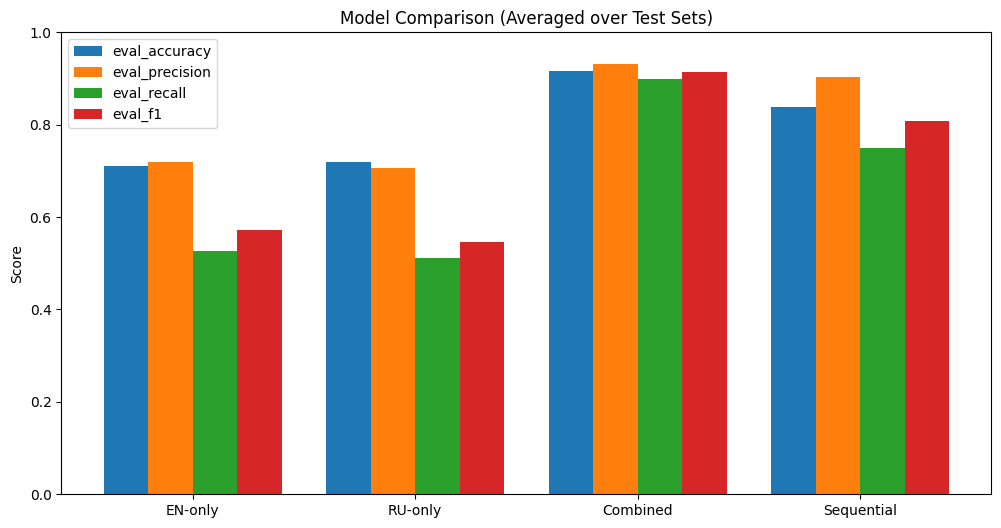

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

metrics = ["eval_accuracy", "eval_precision", "eval_recall", "eval_f1"]

models = results_df["Model"].unique()
tests = ["EN", "RU"]

x = np.arange(len(models))
width = 0.2

fig, ax = plt.subplots(figsize=(12,6))

for i, metric in enumerate(metrics):
    values = []

    for model in models:
        val = results_df[results_df["Model"] == model][metric].mean()
        values.append(val)

    ax.bar(x + (i - 1.5)*width, values, width, label=metric)

ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylim(0, 1)

ax.set_title("Model Comparison (Averaged over Test Sets)")
ax.set_ylabel("Score")
ax.legend()

plt.show()

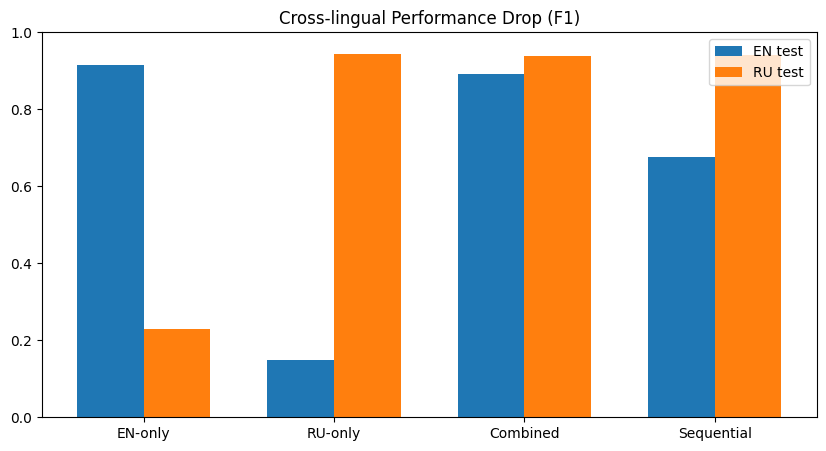

In [ ]:
import matplotlib.pyplot as plt

drop_df = pd.DataFrame({
    "Model": ["EN-only", "RU-only", "Combined", "Sequential"],
    "EN": [
        en_on_en["eval_f1"],
        ru_on_en["eval_f1"],
        combined_on_en["eval_f1"],
        seq_on_en["eval_f1"]
    ],
    "RU": [
        en_on_ru["eval_f1"],
        ru_on_ru["eval_f1"],
        combined_on_ru["eval_f1"],
        seq_on_ru["eval_f1"]
    ]
})

x = np.arange(len(drop_df["Model"]))
width = 0.35

plt.figure(figsize=(10,5))

plt.bar(x - width/2, drop_df["EN"], width, label="EN test")
plt.bar(x + width/2, drop_df["RU"], width, label="RU test")

plt.xticks(x, drop_df["Model"])
plt.ylim(0, 1)

plt.title("Cross-lingual Performance Drop (F1)")
plt.legend()

plt.show()

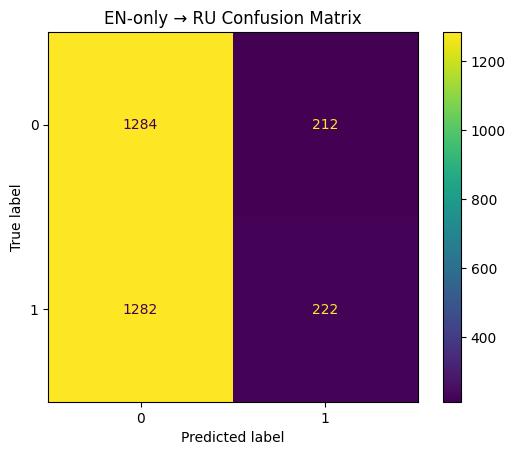

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

preds_en_on_ru = trainer_en.predict(test_ru_ds)

y_true = preds_en_on_ru.label_ids
y_pred = np.argmax(preds_en_on_ru.predictions, axis=1)

cm = confusion_matrix(y_true, y_pred)

ConfusionMatrixDisplay(cm).plot()
plt.title("EN-only → RU Confusion Matrix")
plt.show()

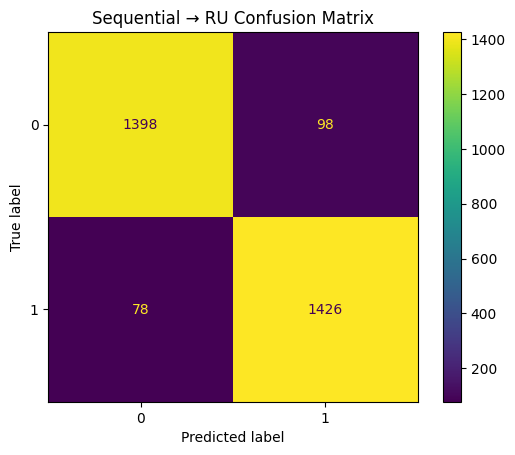

In [ ]:
preds_seq_on_ru = trainer_seq.predict(test_ru_ds)

y_true = preds_seq_on_ru.label_ids
y_pred = np.argmax(preds_seq_on_ru.predictions, axis=1)

cm = confusion_matrix(y_true, y_pred)

ConfusionMatrixDisplay(cm).plot()
plt.title("Sequential → RU Confusion Matrix")
plt.show()

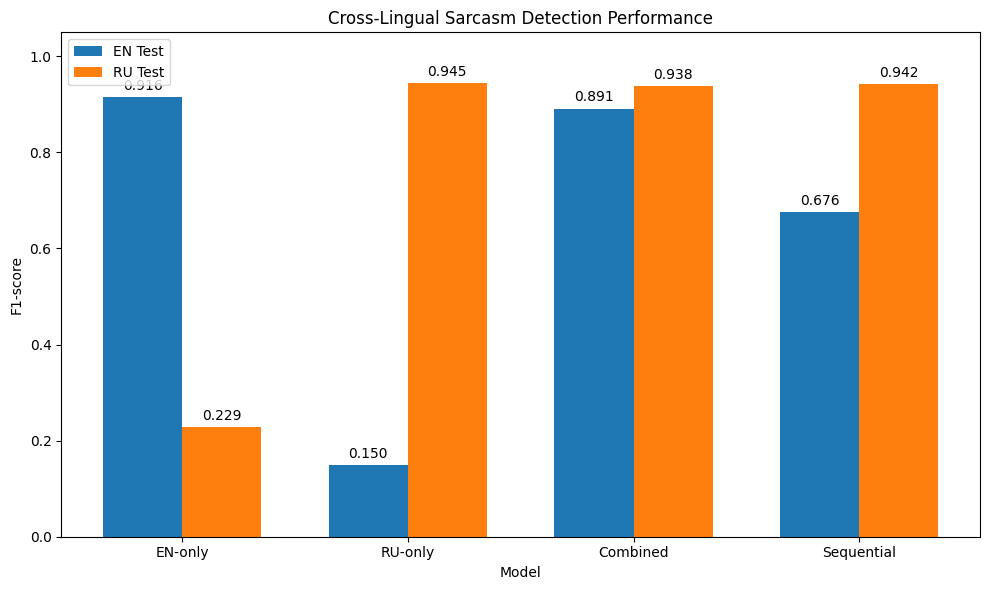

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

pivot_df = results_df.pivot(
    index="Model",
    columns="Test",
    values="eval_f1"
)

pivot_df = pivot_df.loc[
    ["EN-only", "RU-only", "Combined", "Sequential"]
]

x = np.arange(len(pivot_df.index))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

bars_en = ax.bar(
    x - width/2,
    pivot_df["EN"],
    width,
    label="EN Test"
)

bars_ru = ax.bar(
    x + width/2,
    pivot_df["RU"],
    width,
    label="RU Test"
)

ax.set_title("Cross-Lingual Sarcasm Detection Performance")
ax.set_xlabel("Model")
ax.set_ylabel("F1-score")

ax.set_xticks(x)
ax.set_xticklabels(pivot_df.index)

ax.set_ylim(0, 1.05)

ax.legend()

for bars in [bars_en, bars_ru]:
    for bar in bars:
        height = bar.get_height()

        ax.annotate(
            f"{height:.3f}",
            xy=(bar.get_x() + bar.get_width()/2, height),
            xytext=(0, 3),
            textcoords="offset points",
            ha="center",
            va="bottom"
        )

plt.tight_layout()
plt.show()

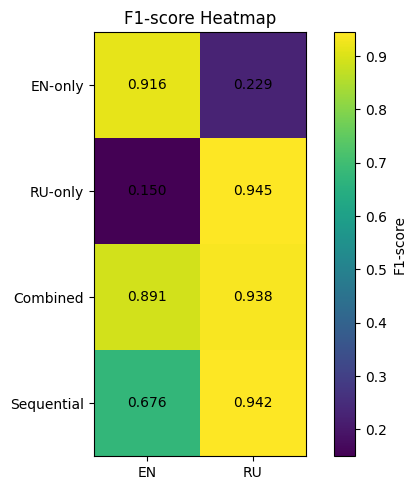

In [ ]:
import matplotlib.pyplot as plt

heatmap_df = results_df.pivot(
    index="Model",
    columns="Test",
    values="eval_f1"
)

heatmap_df = heatmap_df.loc[
    ["EN-only", "RU-only", "Combined", "Sequential"]
]

fig, ax = plt.subplots(figsize=(6, 5))

im = ax.imshow(heatmap_df.values)

ax.set_xticks(range(len(heatmap_df.columns)))
ax.set_xticklabels(heatmap_df.columns)

ax.set_yticks(range(len(heatmap_df.index)))
ax.set_yticklabels(heatmap_df.index)

for i in range(len(heatmap_df.index)):
    for j in range(len(heatmap_df.columns)):
        ax.text(
            j,
            i,
            f"{heatmap_df.iloc[i, j]:.3f}",
            ha="center",
            va="center"
        )

ax.set_title("F1-score Heatmap")

cbar = plt.colorbar(im)
cbar.set_label("F1-score")

plt.tight_layout()
plt.show()

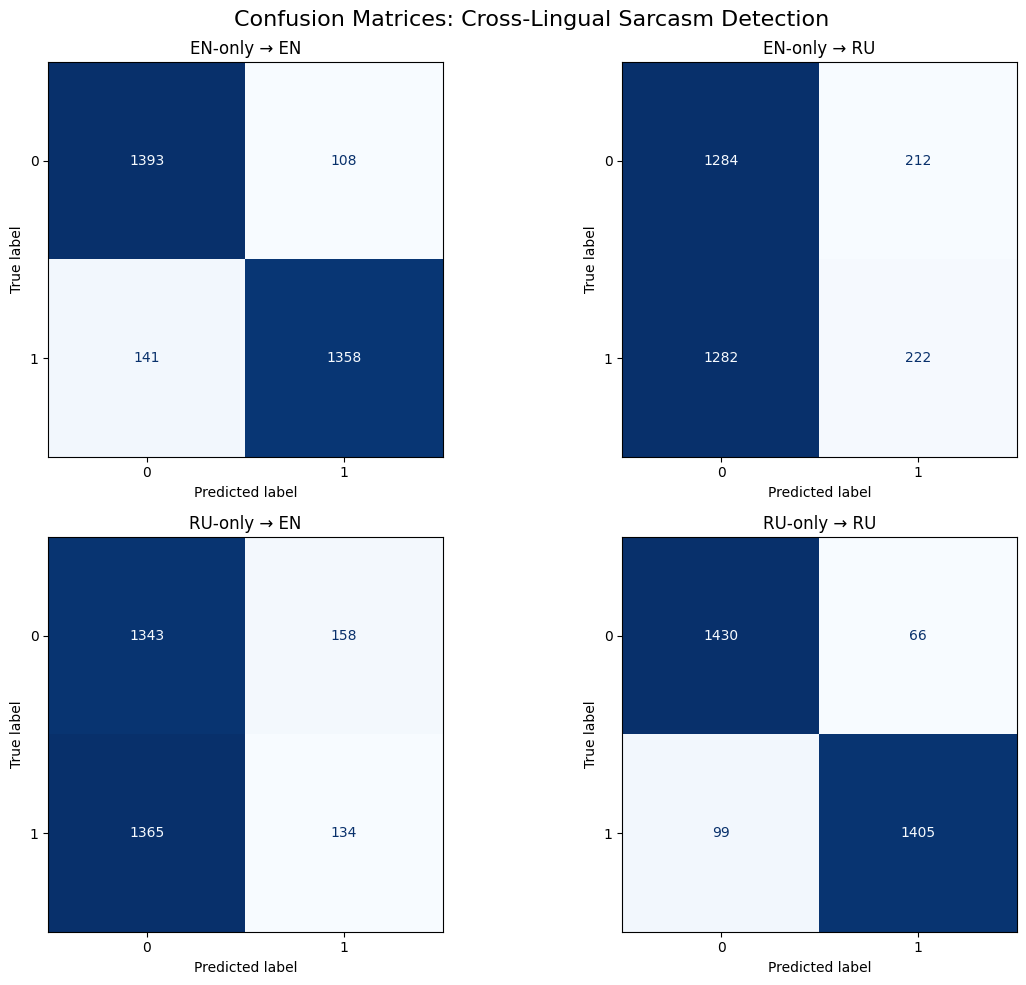

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


def get_pred_labels(preds):
    return preds.predictions.argmax(axis=1)

def plot_cm(ax, y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(ax=ax, colorbar=False, cmap="Blues", values_format="d")
    ax.set_title(title)


fig, axes = plt.subplots(2, 2, figsize=(12, 10))

en_only_en_preds = trainer_en.predict(test_en_ds)
en_only_ru_preds = trainer_en.predict(test_ru_ds)

ru_only_en_preds = trainer_ru.predict(test_en_ds)
ru_only_ru_preds = trainer_ru.predict(test_ru_ds)


plot_cm(
    axes[0, 0],
    en_only_en_preds.label_ids,
    get_pred_labels(en_only_en_preds),
    "EN-only → EN"
)


plot_cm(
    axes[0, 1],
    en_only_ru_preds.label_ids,
    get_pred_labels(en_only_ru_preds),
    "EN-only → RU"
)

plot_cm(
    axes[1, 0],
    ru_only_en_preds.label_ids,
    get_pred_labels(ru_only_en_preds),
    "RU-only → EN"
)

plot_cm(
    axes[1, 1],
    ru_only_ru_preds.label_ids,
    get_pred_labels(ru_only_ru_preds),
    "RU-only → RU"
)


plt.suptitle("Confusion Matrices: Cross-Lingual Sarcasm Detection", fontsize=16)
plt.tight_layout()
plt.show()

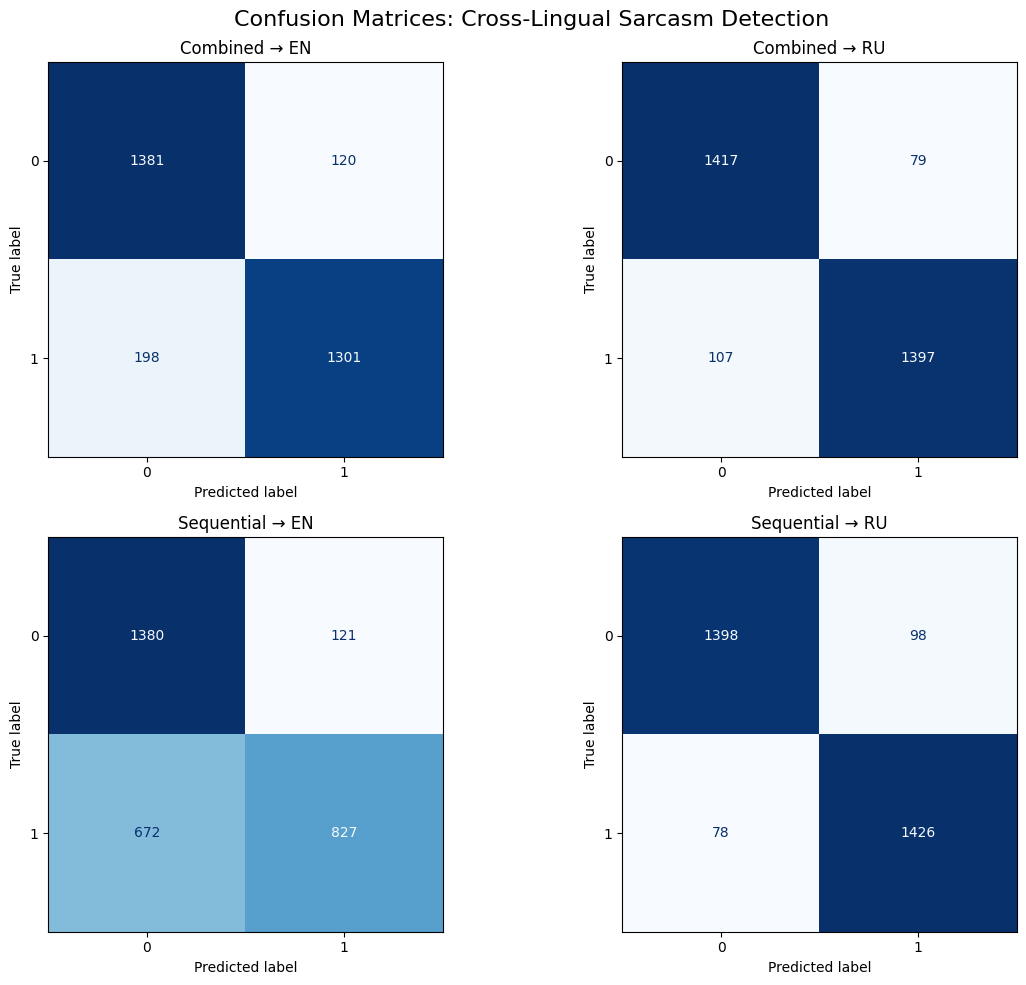

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


def get_pred_labels(preds):
    return preds.predictions.argmax(axis=1)

def plot_cm(ax, y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(ax=ax, colorbar=False, cmap="Blues", values_format="d")
    ax.set_title(title)


fig, axes = plt.subplots(2, 2, figsize=(12, 10))

combined_en_preds = trainer_combined.predict(test_en_ds)
combined_ru_preds = trainer_combined.predict(test_ru_ds)

seq_en_preds = trainer_seq.predict(test_en_ds)
seq_ru_preds = trainer_seq.predict(test_ru_ds)


plot_cm(
    axes[0, 0],
    combined_en_preds.label_ids,
    get_pred_labels(combined_en_preds),
    "Combined → EN"
)


plot_cm(
    axes[0, 1],
    combined_ru_preds.label_ids,
    get_pred_labels(combined_ru_preds),
    "Combined → RU"
)

plot_cm(
    axes[1, 0],
    seq_en_preds.label_ids,
    get_pred_labels(seq_en_preds),
    "Sequential → EN"
)

plot_cm(
    axes[1, 1],
    seq_ru_preds.label_ids,
    get_pred_labels(seq_ru_preds),
    "Sequential → RU"
)


plt.suptitle("Confusion Matrices: Cross-Lingual Sarcasm Detection", fontsize=16)
plt.tight_layout()
plt.show()



**Visualization**

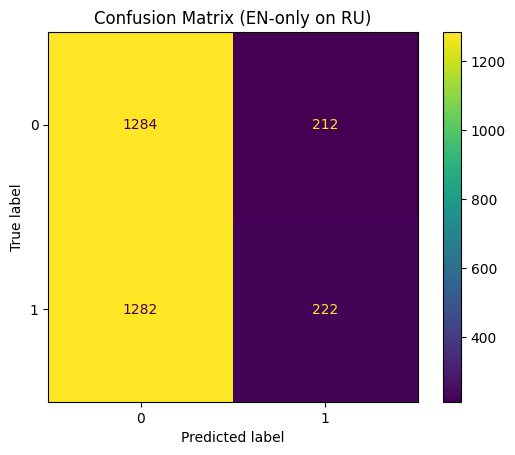

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

preds_en_on_ru = trainer_en.predict(test_ru_ds)

y_true = preds_en_on_ru.label_ids
y_pred = np.argmax(preds_en_on_ru.predictions, axis=1)

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(cm)
disp.plot()

plt.title("Confusion Matrix (EN-only on RU)")
plt.show()

# **Part 2**

Model: https://huggingface.co/docs/transformers/model_doc/nllb

Dataset EN: https://www.kaggle.com/datasets/rmisra/news-headlines-dataset-for-sarcasm-detection

In [ ]:
import pandas as pd
import torch
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
from tqdm.auto import tqdm

In [ ]:
import pandas as pd

test_en = pd.read_csv(f"{BASE_PATH}/data/test_en.csv")
test_en.head()

In [ ]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

model_name = "facebook/nllb-200-distilled-600M"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSeq2SeqLM.from_pretrained(model_name)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = model.to(device)

print("Using device:", device)

In [ ]:
def translate_batch(texts):

    tokenizer.src_lang = "eng_Latn"

    inputs = tokenizer(
        texts,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=128
    )

    inputs = {k: v.to(device) for k, v in inputs.items()}

    translated_tokens = model.generate(
        **inputs,
        forced_bos_token_id=tokenizer.convert_tokens_to_ids("rus_Cyrl"),
        max_length=128
    )

    translated_texts = tokenizer.batch_decode(
        translated_tokens,
        skip_special_tokens=True
    )

    return translated_texts

In [ ]:
batch_size = 16

translated_texts = []

save_path = f"{BASE_PATH}/data/test_en_translated_ru.csv"

for i in tqdm(range(0, len(test_en), batch_size)):

    batch = test_en["text"][i:i + batch_size].fillna("").tolist()

    translated = translate_batch(batch)

    translated_texts.extend(translated)

    for en, ru in zip(batch[:1], translated[:1]):
        print("\nEN:", en)
        print("RU:", ru)
        print("-" * 50)

In [ ]:
test_en["translated_text"] = translated_texts

test_en.to_csv(save_path, index=False)

print("Saved:", save_path)

# **Part 3**

**Model (the best from Part 1):**

**Dataset (MT EN->RU):**

In [ ]:
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt

from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    DataCollatorWithPadding
)

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

In [ ]:
translated_path = "/content/drive/MyDrive/sarcasm_thesis/data/test_en_translated_ru.csv"

df_translated = pd.read_csv(translated_path)

df_translated.head()

,text,label,translated_text
0,robots speak out against asimov's first law of...,1,Роботы выступают против первого закона роботот...
1,australian ambassador gets engaged in paris an...,0,Австралийский посол занимается Парижем и дает ...
2,michele bachmann thankful no americans died in...,1,"Мишель Бахманн благодарен, что не было америка..."
3,white house guidance counselor recommends clin...,1,Советник по рекомендациям в Белом доме рекомен...
4,a quick guide to this year's oscar best pictur...,0,Быстрый справочник к номинированным на этот го...


In [ ]:
df_translated.columns

Index(['text', 'label', 'translated_text'], dtype='object')

In [ ]:
BASE_PATH = "/content/drive/MyDrive/sarcasm_thesis"

model_path = f"{BASE_PATH}/models/combined_only"

tokenizer = AutoTokenizer.from_pretrained(model_path)

model = AutoModelForSequenceClassification.from_pretrained(model_path)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

print("Using device:", device)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Using device: cuda


In [ ]:
eval_df = df_translated[["translated_text", "label"]].copy()

eval_df = eval_df.rename(columns={
    "translated_text": "text"
})

eval_df["text"] = eval_df["text"].fillna("").astype(str)
eval_df["label"] = eval_df["label"].astype(int)

translated_ds = Dataset.from_pandas(eval_df)

In [ ]:
def tokenize_function(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        max_length=128
    )

translated_ds = translated_ds.map(tokenize_function, batched=True)

translated_ds = translated_ds.remove_columns(["text"])
translated_ds.set_format("torch")

Map:   0%|          | 0/3000 [00:00<?, ? examples/s]

In [ ]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = logits.argmax(axis=1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        preds,
        average="binary"
    )

    acc = accuracy_score(labels, preds)

    return {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

In [ ]:
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

eval_args = TrainingArguments(
    output_dir="./tmp_eval_translated",
    per_device_eval_batch_size=16,
    report_to=[],
    logging_strategy="no"
)

trainer_translated = Trainer(
    model=model,
    args=eval_args,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

In [ ]:
!pip install numpy==1.26.4 --force-reinstall

translated_results = trainer_translated.evaluate(translated_ds)

translated_results

  Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.0 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
jax 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
rasterio 1.5.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
opencv-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is 

{'eval_loss': 2.9126060009002686,
 'eval_model_preparation_time': 0.0048,
 'eval_accuracy': 0.5956666666666667,
 'eval_precision': 0.8592964824120602,
 'eval_recall': 0.22815210140093395,
 'eval_f1': 0.36056931997891406,
 'eval_runtime': 9.275,
 'eval_samples_per_second': 323.449,
 'eval_steps_per_second': 20.269}

In [ ]:
pred_output = trainer_translated.predict(translated_ds)

logits = pred_output.predictions
true_labels = pred_output.label_ids

pred_labels = logits.argmax(axis=1)

probs = torch.softmax(torch.tensor(logits), dim=1).numpy()

prob_non_sarcastic = probs[:, 0]
prob_sarcastic = probs[:, 1]

In [ ]:
save_predictions_path = f"{BASE_PATH}/data/test_en_translated_ru_with_predictions.csv"

df_translated.to_csv(save_predictions_path, index=False)

print("Saved:", save_predictions_path)

Saved: /content/drive/MyDrive/sarcasm_thesis/data/test_en_translated_ru_with_predictions.csv


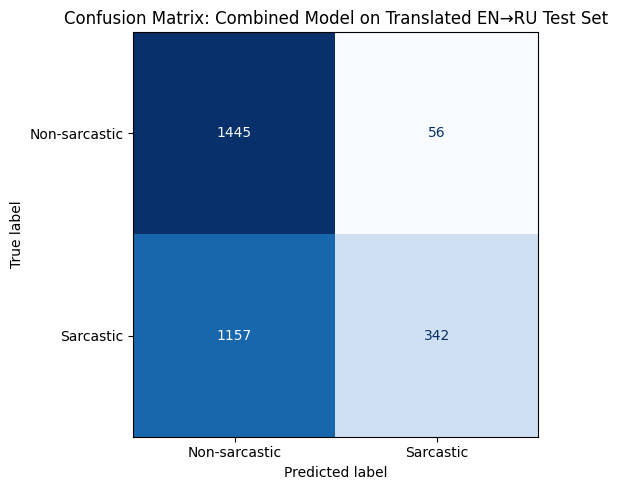

In [ ]:
cm = confusion_matrix(true_labels, pred_labels)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Non-sarcastic", "Sarcastic"]
)

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap="Blues", values_format="d", colorbar=False)

ax.set_title("Confusion Matrix: Combined Model on Translated EN→RU Test Set")

plt.tight_layout()
plt.show()

In [ ]:
print(classification_report(
    true_labels,
    pred_labels,
    target_names=["Non-sarcastic", "Sarcastic"]
))

               precision    recall  f1-score   support

Non-sarcastic       0.56      0.96      0.70      1501
    Sarcastic       0.86      0.23      0.36      1499

     accuracy                           0.60      3000
    macro avg       0.71      0.60      0.53      3000
 weighted avg       0.71      0.60      0.53      3000



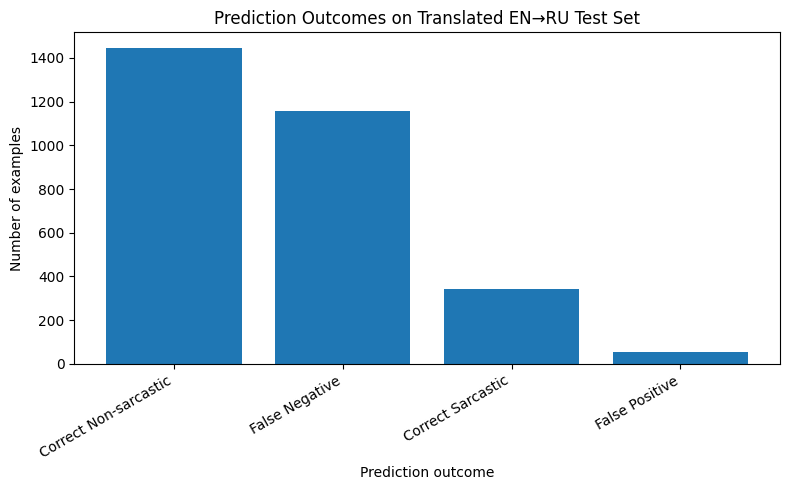

In [ ]:
df_translated["error_type"] = ""

df_translated.loc[(true_labels == 1) & (pred_labels == 1), "error_type"] = "Correct Sarcastic"
df_translated.loc[(true_labels == 0) & (pred_labels == 0), "error_type"] = "Correct Non-sarcastic"
df_translated.loc[(true_labels == 0) & (pred_labels == 1), "error_type"] = "False Positive"
df_translated.loc[(true_labels == 1) & (pred_labels == 0), "error_type"] = "False Negative"

error_counts = df_translated["error_type"].value_counts()

fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(error_counts.index, error_counts.values)

ax.set_title("Prediction Outcomes on Translated EN→RU Test Set")
ax.set_ylabel("Number of examples")
ax.set_xlabel("Prediction outcome")

plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

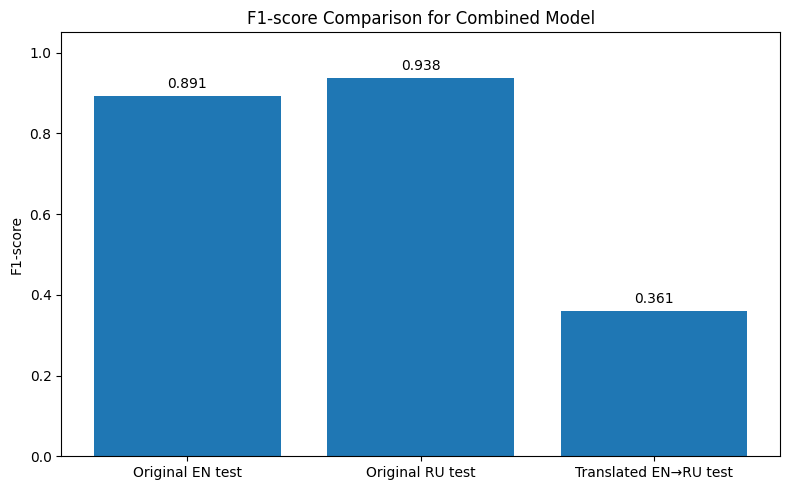

In [ ]:
combined_on_en = {'eval_f1': 0.8910958904109589}
combined_on_ru = {'eval_f1': 0.9375838926174497}

f1_comparison = pd.DataFrame({
    "Dataset": [
        "Original EN test",
        "Original RU test",
        "Translated EN→RU test"
    ],
    "F1": [
        combined_on_en["eval_f1"],
        combined_on_ru["eval_f1"],
        translated_results["eval_f1"]
    ]
})

fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(
f1_comparison["Dataset"],
    f1_comparison["F1"]
)

ax.set_title("F1-score Comparison for Combined Model")
ax.set_ylabel("F1-score")
ax.set_ylim(0, 1.05)

for i, value in enumerate(f1_comparison["F1"]):
    ax.text(i, value + 0.02, f"{value:.3f}", ha="center")

plt.tight_layout()
plt.show()

In [ ]:
df_translated["predicted_label"] = pred_labels
df_translated["prob_sarcastic"] = prob_sarcastic

preserved_sarcasm = df_translated[
    (df_translated["label"] == 1) &
    (df_translated["predicted_label"] == 1)
]

preserved_sarcasm[[
    "text",
    "translated_text",
    "label",
    "predicted_label",
    "prob_sarcastic"
]].head(100)

,text,translated_text,label,predicted_label,prob_sarcastic
5,report: it a miracle nothing has punctured you...,"Отчет: это чудо, что ничто еще не прорвало теб...",1,1,0.998530
6,ice cube thrown into sink flies up side like s...,"Кубик льда, брошенный в раковину, летит вверх,...",1,1,0.990067
12,tan asshole still on island time,Бедный дурак все еще на острове.,1,1,0.974460
15,"straight, gay service members looking forward ...","Гей-служащие с нетерпением ждут, когда спросят...",1,1,0.993938
22,coworker who just threw fit and stormed out of...,"Коллега, который просто бросил форму и вырвалс...",1,1,0.556554
...,...,...,...,...,...
819,george clooney beginning to think he should bu...,"Джордж Клуни начинает думать, что он должен ку...",1,1,0.829831
820,family chooses different dog than reincarnated...,"Семья выбирает другого собаки, чем реинкарниро...",1,1,0.985456
827,area man can't wait to get home to look out ne...,"Человек с нетерпением ждет, когда он вернется ...",1,1,0.530120
828,sources: nfl knew what evil lurking within hea...,"Источники: nfl знал, что зло скрывается в серд...",1,1,0.998841


In [ ]:
df_translated["predicted_label"] = pred_labels
df_translated["prob_sarcastic"] = prob_sarcastic

preserved_sarcasm = df_translated[
    (df_translated["label"] == 1) &
    (df_translated["predicted_label"] == 0)
]

preserved_sarcasm[[
    "text",
    "translated_text",
    "label",
    "predicted_label",
    "prob_sarcastic"
]].head(100)

,text,translated_text,label,predicted_label,prob_sarcastic
0,robots speak out against asimov's first law of...,Роботы выступают против первого закона роботот...,1,0,0.000176
2,michele bachmann thankful no americans died in...,"Мишель Бахманн благодарен, что не было америка...",1,0,0.000425
3,white house guidance counselor recommends clin...,Советник по рекомендациям в Белом доме рекомен...,1,0,0.000293
8,history channel admits to profiting from nazi ...,"History Channel признается, что получает прибы...",1,0,0.000675
9,blotting of ken olin from human memory delayed...,Удаление Кен Олина из человеческой памяти затя...,1,0,0.000213
...,...,...,...,...,...
216,monopoly releases special 'regular monopoly' e...,"Monopoly выпускает специальное издание ""Регуля...",1,0,0.000223
218,climate experts say only hope for saving plane...,"По мнению экспертов по климату, единственная н...",1,0,0.000487
229,lucky bastard gets to be in coma,Бедный ублюдок попал в коме.,1,0,0.000185
231,man listening to 'highway to hell' actually on...,"Слушая ""Шоссе к человеку в ад"" на самом деле н...",1,0,0.000255


**Translation Quality (COMET-QE and BERTScore\)**

COMET-QE

In [ ]:
!pip install bert-score

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 1.9 MB/s eta 0:00:00


In [ ]:
import pandas as pd
from bert_score import score

translated_path = "/content/drive/MyDrive/sarcasm_thesis/data/test_en_translated_ru.csv"

df = pd.read_csv(translated_path)

df = df[["text", "translated_text", "label"]].dropna()

src_texts = df["text"].astype(str).tolist()
mt_texts = df["translated_text"].astype(str).tolist()

In [ ]:
P, R, F1 = score(
    cands=mt_texts,
    refs=src_texts,
    model_type="bert-base-multilingual-cased",
    lang="ru",
    verbose=True,
    batch_size=16,
    device="cuda"
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.96M [00:00<?, ?B/s]

...

calculating scores...
computing bert embedding.


  0%|          | 0/375 [00:00<?, ?it/s]

computing greedy matching.


  0%|          | 0/188 [00:00<?, ?it/s]

done in 10.85 seconds, 276.42 sentences/sec


In [ ]:
df["bertscore_precision"] = P.cpu().numpy()
df["bertscore_recall"] = R.cpu().numpy()
df["bertscore_f1"] = F1.cpu().numpy()

print("Average BERTScore Precision:", df["bertscore_precision"].mean())
print("Average BERTScore Recall:", df["bertscore_recall"].mean())
print("Average BERTScore F1:", df["bertscore_f1"].mean())

Average BERTScore Precision: 0.7025077
Average BERTScore Recall: 0.7209373
Average BERTScore F1: 0.7114425


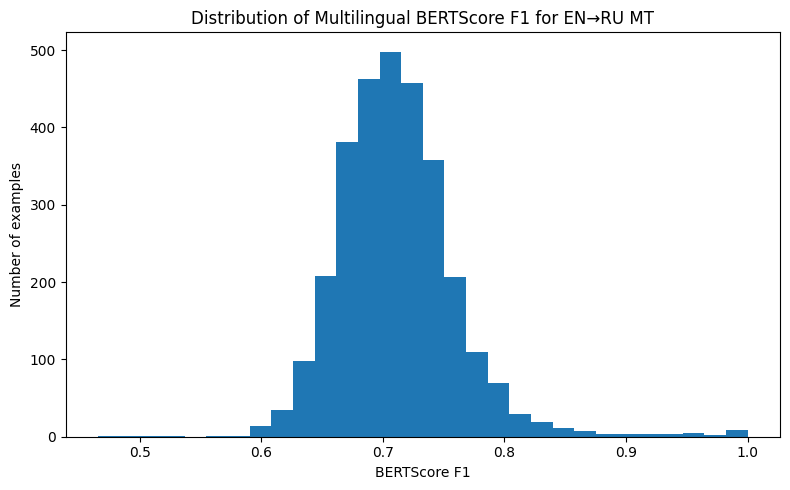

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(df["bertscore_f1"], bins=30)

plt.title("Distribution of Multilingual BERTScore F1 for EN→RU MT")
plt.xlabel("BERTScore F1")
plt.ylabel("Number of examples")

plt.tight_layout()
plt.show()

In [ ]:
df.groupby("label")["bertscore_f1"].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,1501.0,0.716512,0.048904,0.518676,0.683679,0.714175,0.74192,1.0
1,1499.0,0.706366,0.049448,0.465812,0.675612,0.702475,0.73135,1.0


<Figure size 600x500 with 0 Axes>

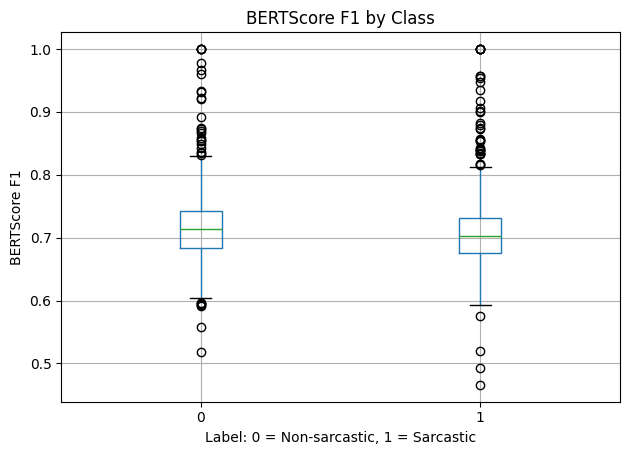

In [ ]:
plt.figure(figsize=(6, 5))

df.boxplot(column="bertscore_f1", by="label")

plt.title("BERTScore F1 by Class")
plt.suptitle("")
plt.xlabel("Label: 0 = Non-sarcastic, 1 = Sarcastic")
plt.ylabel("BERTScore F1")

plt.tight_layout()
plt.show()

COMET-QE

In [ ]:
!pip install unbabel-comet

In [ ]:
import os
os.environ["USE_TF"] = "0"
os.environ["TRANSFORMERS_NO_TF"] = "1"
os.environ["USE_FLAX"] = "0"

In [ ]:
import pandas as pd
import torch
from comet import download_model, load_from_checkpoint

translated_path = "/content/drive/MyDrive/sarcasm_thesis/data/test_en_translated_ru.csv"

df = pd.read_csv(translated_path)
df = df[["text", "translated_text", "label"]].dropna()

df.head()

,text,translated_text,label
0,robots speak out against asimov's first law of...,Роботы выступают против первого закона роботот...,1
1,australian ambassador gets engaged in paris an...,Австралийский посол занимается Парижем и дает ...,0
2,michele bachmann thankful no americans died in...,"Мишель Бахманн благодарен, что не было америка...",1
3,white house guidance counselor recommends clin...,Советник по рекомендациям в Белом доме рекомен...,1
4,a quick guide to this year's oscar best pictur...,Быстрый справочник к номинированным на этот го...,0


In [ ]:
!huggingface-cli login

⚠️  Warning: 'huggingface-cli login' is deprecated. Use 'hf auth login' instead.

    _|    _|  _|    _|    _|_|_|    _|_|_|  _|_|_|  _|      _|    _|_|_|      _|_|_|_|    _|_|      _|_|_|  _|_|_|_|
    _|    _|  _|    _|  _|        _|          _|    _|_|    _|  _|            _|        _|    _|  _|        _|
    _|_|_|_|  _|    _|  _|  _|_|  _|  _|_|    _|    _|  _|  _|  _|  _|_|      _|_|_|    _|_|_|_|  _|        _|_|_|
    _|    _|  _|    _|  _|    _|  _|    _|    _|    _|    _|_|  _|    _|      _|        _|    _|  _|        _|
    _|    _|    _|_|      _|_|_|    _|_|_|  _|_|_|  _|      _|    _|_|_|      _|        _|    _|    _|_|_|  _|_|_|_|

    To log in, `huggingface_hub` requires a token generated from https://huggingface.co/settings/tokens .
Enter your token (input will not be visible): 
Add token as git credential? (Y/n) Y
Token is valid (permission: read).
The token `MTFU1` has been saved to /root/.cache/huggingface/stored_tokens
Cannot authenticate through git-credential as 

In [ ]:
from comet import download_model, load_from_checkpoint

model_path = download_model("Unbabel/wmt22-cometkiwi-da")
comet_model = load_from_checkpoint(model_path)

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

.gitattributes: 0.00B [00:00, ?B/s]

hparams.yaml:   0%|          | 0.00/716 [00:00<?, ?B/s]

checkpoints/model.ckpt:   0%|          | 0.00/2.26G [00:00<?, ?B/s]

INFO:pytorch_lightning.utilities.migration.utils:Lightning automatically upgraded your loaded checkpoint from v1.8.2 to v2.6.5. To apply the upgrade to your files permanently, run `python -m pytorch_lightning.utilities.upgrade_checkpoint ../root/.cache/huggingface/hub/models--Unbabel--wmt22-cometkiwi-da/snapshots/1ad785194e391eebc6c53e2d0776cada8f83179a/checkpoints/model.ckpt`


sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/513 [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/core/saving.py:197: Found keys that are not in the model state dict but in the checkpoint: ['encoder.model.embeddings.position_ids']


In [ ]:
data = [
    {
        "src": row["text"],
        "mt": row["translated_text"]
    }
    for _, row in df.iterrows()
]

In [ ]:
gpus = 1 if torch.cuda.is_available() else 0

comet_output = comet_model.predict(
    data,
    batch_size=8,
    gpus=gpus
)

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
Predicting DataLoader 0: 100%|

In [ ]:
df["comet_qe_score"] = comet_output.scores

print("Average COMET-QE:", df["comet_qe_score"].mean())
print("Median COMET-QE:", df["comet_qe_score"].median())
print("Min COMET-QE:", df["comet_qe_score"].min())
print("Max COMET-QE:", df["comet_qe_score"].max())

Average COMET-QE: 0.7218849904835224
Median COMET-QE: 0.7653188109397888
Min COMET-QE: 0.1840815246105194
Max COMET-QE: 0.8996230959892273


In [ ]:
save_path = "/content/drive/MyDrive/sarcasm_thesis/data/test_en_translated_ru_with_comet_qe.csv"

df.to_csv(save_path, index=False)

print("Saved:", save_path)

Saved: /content/drive/MyDrive/sarcasm_thesis/data/test_en_translated_ru_with_comet_qe.csv


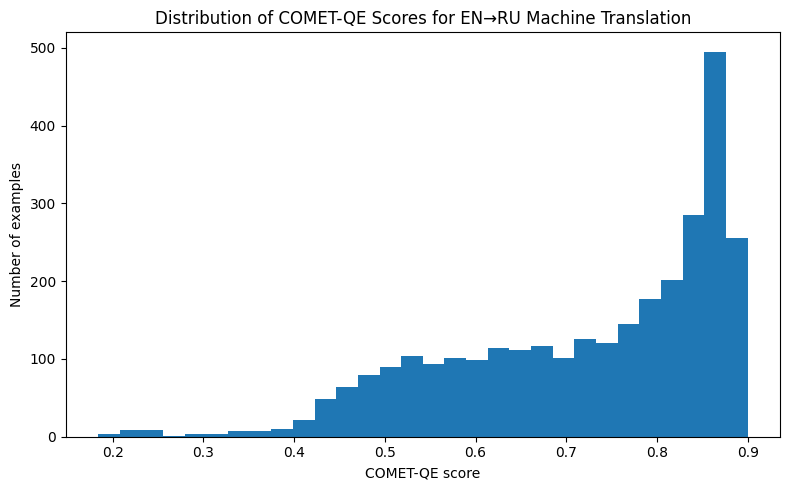

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(df["comet_qe_score"], bins=30)

plt.title("Distribution of COMET-QE Scores for EN→RU Machine Translation")
plt.xlabel("COMET-QE score")
plt.ylabel("Number of examples")

plt.tight_layout()
plt.show()

In [ ]:
df.groupby("label")["comet_qe_score"].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,1501.0,0.754725,0.136903,0.208328,0.664879,0.807909,0.866109,0.899623
1,1499.0,0.689001,0.148850,0.184082,0.570170,0.715267,0.826194,0.897839


<Figure size 600x500 with 0 Axes>

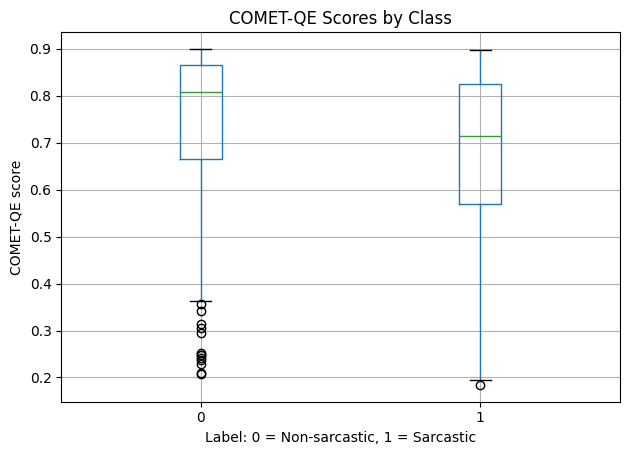

In [ ]:
plt.figure(figsize=(6, 5))

df.boxplot(column="comet_qe_score", by="label")

plt.title("COMET-QE Scores by Class")
plt.suptitle("")
plt.xlabel("Label: 0 = Non-sarcastic, 1 = Sarcastic")
plt.ylabel("COMET-QE score")

plt.tight_layout()
plt.show()

In [ ]:
df.sort_values("comet_qe_score").head(20)

,text,translated_text,label,comet_qe_score
2241,hand drum after hand drum emerges from vw bus,Ручная барабанная барабанная барабанная бараба...,1,0.184082
2256,webster's reluctantly adds 'melty' to english ...,Webster's reluctantly adds 'melty' to english ...,1,0.193873
1953,bumper nilla crop spells profit for wafer growers,bumper nilla crop spells profit for wafer growers,1,0.200504
944,cnn panel gets in tense battle over caitlyn je...,panel cnn gets in tense battle over caitlyn je...,0,0.208328
508,ask a queer chick: my mom says i'm claiming to...,ask a queer chick: my mom says i'm claiming to...,0,0.210356
806,bush calls in national marching band to lift u...,Bush calls in national marching band to lift U...,1,0.210889
1804,fred durst spray paints 'limp bizkit' on bridge,Durst spray paints 'limp bizkit' on bridge fred,1,0.219294
106,"paul ryan mentally logs 4,613th missed opportu...",paul ryan mentally logs 4613th missed opportun...,1,0.219888
492,samantha bee goes full 'schoolhouse rock' with...,Самаantha bee goes full 'schoolhouse rock' wit...,0,0.228089
1381,parole board swayed by reverse psychology,Разозобновляемый совет по освобождению от своб...,1,0.229282


In [ ]:
df.sort_values("comet_qe_score", ascending=False).head(20)

,text,translated_text,label,comet_qe_score
1034,poland passes law that eu says threatens count...,"Польша приняла закон, который ЕС считает угроз...",0,0.899623
846,pope visits one of italy's most dangerous areas,Папа посещает один из самых опасных районов Ит...,0,0.898802
825,astronomers celebrate 300th anniversary of dis...,Астрономы отмечают 300-летие открытия неба.,1,0.897839
2004,modern day activists call it 'historic trauma',"Современные активисты называют это ""историческ...",0,0.894777
1513,former pennsylvania congressman sentenced to 1...,Бывший конгрессмен из Пенсильвании был пригово...,0,0.894580
2797,greece sees slight uptick in refugee arrivals ...,Греция в августе отметила небольшой рост числа...,0,0.893632
462,"u.s. obesity rates are rising again, especiall...","В США ожирение снова растет, особенно среди же...",0,0.893435
1797,austria legalizes same-sex marriage,Австрия легализует однополые браки.,0,0.893371
906,syrian kurds say bashar assad is thwarting hum...,"Сирийские курды говорят, что Башар Асад мешает...",0,0.893321
337,palestinian teen dies after being shot by isra...,"Палестинский подросток погиб после того, как б...",0,0.893211
